# DATA CLEANING


## STEP1. DATA LOADING AND INSPECTION
 During the course of loading and inspecting the dataset, we will try to get a feel of the dataset before touching anything. The goal is to check the size, data type, missing values, etc and to have an indepth understanding of the data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df = pd.read_csv('outbreaks.csv')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

### i. df.head()
This command prints the first five (5) of the dataset.

In [ ]:
df.head()

,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
0,Switzerland,CH,CHE,2026,Other viral diseases,"Other viral diseases, not elsewhere classified",Hantavirus (cardio-)pulmonary syndrome,B25-B34,B33,B334,1,D62,1D62,Certain infectious or parasitic diseases,Certain zoonotic viral diseases,Hantavirus disease,Hantavirus pulmonary syndrome,DON2948,An acute zoonotic viral disease characterised ...
1,Saint Helena Ascension and Tristan da Cunha,SH,SHN,2026,Other viral diseases,"Other viral diseases, not elsewhere classified",Hantavirus (cardio-)pulmonary syndrome,B25-B34,B33,B334,1,D62,1D62,Certain infectious or parasitic diseases,Certain zoonotic viral diseases,Hantavirus disease,Hantavirus pulmonary syndrome,DON2947,An acute zoonotic viral disease characterised ...
2,South Africa,ZA,ZAF,2026,Other viral diseases,"Other viral diseases, not elsewhere classified",Hantavirus (cardio-)pulmonary syndrome,B25-B34,B33,B334,1,D62,1D62,Certain infectious or parasitic diseases,Certain zoonotic viral diseases,Hantavirus disease,Hantavirus pulmonary syndrome,DON2947,An acute zoonotic viral disease characterised ...
3,Bangladesh,BD,BGD,2026,Viral infections characterized by skin and muc...,Measles,Measles,B00-B09,B05,B05,1,F03,1F03,Certain infectious or parasitic diseases,Viral infections characterised by skin or muco...,Measles,Measles,DON2946,"A disease of the respiratory system, caused by..."
4,Italy,IT,ITA,2026,Influenza and pneumonia,Influenza due to identified zoonotic or pandem...,Influenza due to identified zoonotic or pandem...,J09-J18,J09,J090,1,E31,1E31,Certain infectious or parasitic diseases,Influenza,Influenza,Influenza due to identified zoonotic or pandem...,DON2945,"Influenza, caused by influenza virus strains o..."


In [ ]:
df.shape

(3540, 19)

### ii. df.shape
this tells us how many rows and columns our dataset contains. As we can see in the code cell above, our dataset contains 3540 rows and 19 colums.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3540 entries, 0 to 3539
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Country     3540 non-null   object
 1   iso2        3534 non-null   object
 2   iso3        3540 non-null   object
 3   Year        3540 non-null   int64 
 4   icd10n      3540 non-null   object
 5   icd103n     3540 non-null   object
 6   icd104n     3540 non-null   object
 7   icd10c      3540 non-null   object
 8   icd103c     3540 non-null   object
 9   icd104c     3540 non-null   object
 10  icd11c1     3540 non-null   object
 11  icd11c2     3540 non-null   object
 12  icd11c3     3540 non-null   object
 13  icd11l1     3540 non-null   object
 14  icd11l2     3527 non-null   object
 15  icd11l3     3527 non-null   object
 16  Disease     3540 non-null   object
 17  DONs        3540 non-null   object
 18  Definition  3417 non-null   object
dtypes: int64(1), object(18)
memory usage: 525.6+ KB


### iii. df.info
this gives a quick summary of the dataset. It provides an overview of the structure of the dataset, data types and memory usage.

In [ ]:
df.describe()

,Year
count,3540.000000
mean,2016.480226
std,8.877993
min,1996.000000
25%,2009.000000
50%,2021.000000
75%,2023.000000
max,2026.000000


### iv. df.describe()
This gives a statistical summary of the dataset.

## STEP 2. DATA CLEANING

Before modelling, we need to inspect the dataset for quality issues. We will check for:
- Missing values
- Duplicate rows
- Incorrect data types
- Irrelevant columns

Every cleaning decision will be justified.

## STEP 2.1. Checking for duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

After checking for duplicated rows, we can see that there are zero duplicated rows in our dataset. Hence, we will not go on to drop any duplicates.

## STEP2.2. HANDLING MISSING VALUES

In [ ]:
print(df.isnull().sum())
print(f'Total missing values: {df.isnull().sum().sum()}')

Country         0
iso2            6
iso3            0
Year            0
icd10n          0
icd103n         0
icd104n         0
icd10c          0
icd103c         0
icd104c         0
icd11c1         0
icd11c2         0
icd11c3         0
icd11l1         0
icd11l2        13
icd11l3        13
Disease         0
DONs            0
Definition    123
dtype: int64
Total missing values: 155


### i. df.isnull().sum()
This prints the number of missing values we have in each column. The next step is fixing the missing values.
### ii. df.isnull().sum().sum()
This prints the total number of missing values in the dataset.

###STEP2.2.1 Dropping Irrelevant Columns

The dataset contains 19 columns, many of which are ICD classification codes (e.g., `icd10c`, `icd103c`, `icd104c`, `icd11c1`, `icd11c2`, `icd11c3`) and a `Definition` column containing long text descriptions of each disease.

**Reasoning for dropping:**
- The ICD *code* columns are numeric/alphanumeric identifiers that duplicate the information already captured by the ICD *name* columns (`icd10n`, `icd103n`, `icd104n`, `icd11l1`, `icd11l2`, `icd11l3`). Keeping both would introduce redundancy without adding clustering value.
- The `Definition` column is free text and is not suitable as a clustering feature without NLP preprocessing, which is out of scope for this project.
- The `DONs` column is an internal WHO document reference ID — it has no predictive or clustering value.
- `iso2` is redundant with `iso3` and `Country`; we will keep `iso3` as the standard country identifier.

We retain: `Country`, `iso3`, `Year`, `Disease`, `icd10n` (disease category), `icd103n` (disease subcategory).

In [ ]:
# Drop irrelevant columns
# Assisted by Claude AI, adapted for this dataset
columns_to_drop = [
    'iso2',         # Redundant with iso3 and Country
    'icd10c',       # ICD-10 code — duplicates icd10n (name)
    'icd103c',      # ICD-10 subtype code — duplicates icd103n
    'icd104c',      # ICD-10 disease code — duplicates icd104n
    'icd11c1',      # ICD-11 code — duplicates icd11l1
    'icd11c2',      # ICD-11 subtype code — duplicates icd11l2
    'icd11c3',      # ICD-11 disease code — duplicates icd11l3
    'icd104n',      # Too granular — icd103n is sufficient
    'icd11l1',      # Duplicates icd10n at a broader level
    'icd11l2',      # Duplicates icd103n
    'icd11l3',      # Duplicates Disease column
    'DONs',         # Internal WHO reference ID — no clustering value
    'Definition'    # Free text — not suitable as a clustering feature
]

df_clean = df.drop(columns=columns_to_drop)
print(f'Columns after dropping irrelevant ones: {df_clean.columns.tolist()}')
print(f'New shape: {df_clean.shape}')

Columns after dropping irrelevant ones: ['Country', 'iso3', 'Year', 'icd10n', 'icd103n', 'Disease']
New shape: (3540, 6)


In [ ]:
# Final check — confirm no missing values in our working columns
print('Missing values in cleaned dataset:')
print(df_clean.isnull().sum())
print()
print('Dataset summary:')
df_clean.describe(include='all')

Missing values in cleaned dataset:
Country    0
iso3       0
Year       0
icd10n     0
icd103n    0
Disease    0
dtype: int64

Dataset summary:


,Country,iso3,Year,icd10n,icd103n,Disease
count,3540,3540,3540.000000,3540,3540,3540
unique,236,236,NaN,24,59,92
top,Congo Democratic Republic of the,COD,NaN,Provisional assignment of new diseases of unce...,Emergency use of U07,COVID-19
freq,79,79,NaN,1285,1209,1209
mean,NaN,NaN,2016.480226,NaN,NaN,NaN
std,NaN,NaN,8.877993,NaN,NaN,NaN
min,NaN,NaN,1996.000000,NaN,NaN,NaN
25%,NaN,NaN,2009.000000,NaN,NaN,NaN
50%,NaN,NaN,2021.000000,NaN,NaN,NaN
75%,NaN,NaN,2023.000000,NaN,NaN,NaN


We can clearly see here, we no longer have missing values as we dropped the columns due to duplication in columns data as that isn't detectable and also as most of the columns cannot be used and will not be used in clustering, thus leaving only relevant columns and the changes in the dataset is also visble when we view the first five columns.

In [ ]:
df_clean.head()

,Country,iso3,Year,icd10n,icd103n,Disease
0,Switzerland,CHE,2026,Other viral diseases,"Other viral diseases, not elsewhere classified",Hantavirus pulmonary syndrome
1,Saint Helena Ascension and Tristan da Cunha,SHN,2026,Other viral diseases,"Other viral diseases, not elsewhere classified",Hantavirus pulmonary syndrome
2,South Africa,ZAF,2026,Other viral diseases,"Other viral diseases, not elsewhere classified",Hantavirus pulmonary syndrome
3,Bangladesh,BGD,2026,Viral infections characterized by skin and muc...,Measles,Measles
4,Italy,ITA,2026,Influenza and pneumonia,Influenza due to identified zoonotic or pandem...,Influenza due to identified zoonotic or pandem...


### Step 3. Exploratory Data Analysis (EDA)

EDA helps us understand the structure and distribution of our data before modelling. Each visualisation below is followed by an interpretation that connects to our preprocessing and modelling decisions.

### 3.1 Distribution of Outbreaks by Year

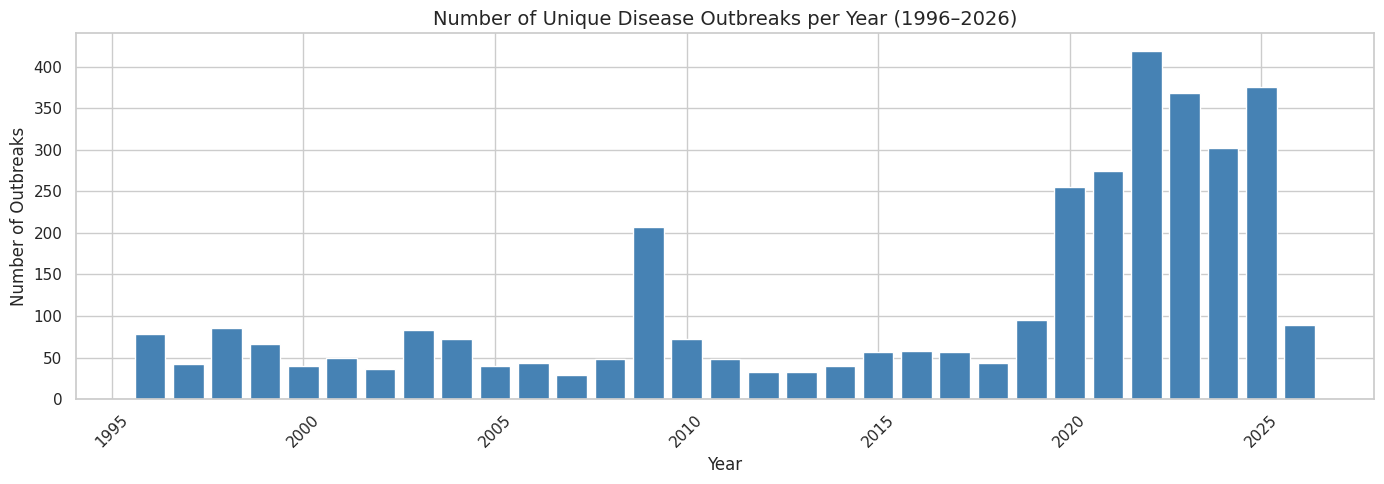

In [ ]:
yearly_counts = df_clean['Year'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(yearly_counts.index, yearly_counts.values, color='steelblue', edgecolor='white')
plt.title('Number of Unique Disease Outbreaks per Year (1996–2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Outbreaks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** There is a notable spike in outbreaks around 2020–2021, which corresponds to the COVID-19 pandemic. This temporal variation is important as it tells us that Year will be a meaningful feature in our clustering model, as certain time periods cluster distinctly from others.

### 3.2 Top 20 Countries by Number of Outbreaks

/tmp/ipykernel_1628/1000917446.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


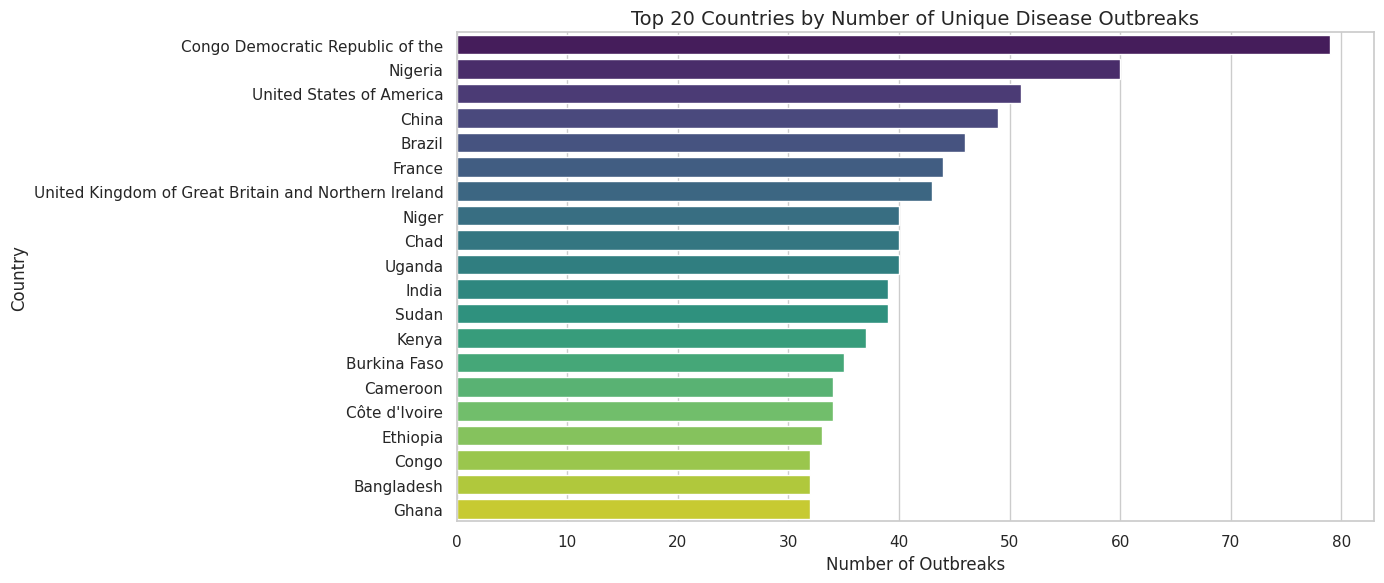

In [ ]:
top_countries = df_clean['Country'].value_counts().head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 20 Countries by Number of Unique Disease Outbreaks', fontsize=14)
plt.xlabel('Number of Outbreaks')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Observation:** African nations such as the Democratic Republic of the Congo and Nigeria dominate the top outbreak counts, alongside large nations like the USA and China. This geographic concentration suggests that clustering by country frequency will produce distinct regional groupings, particularly for Sub-Saharan Africa.

### 3.3 Top 15 Most Frequent Diseases

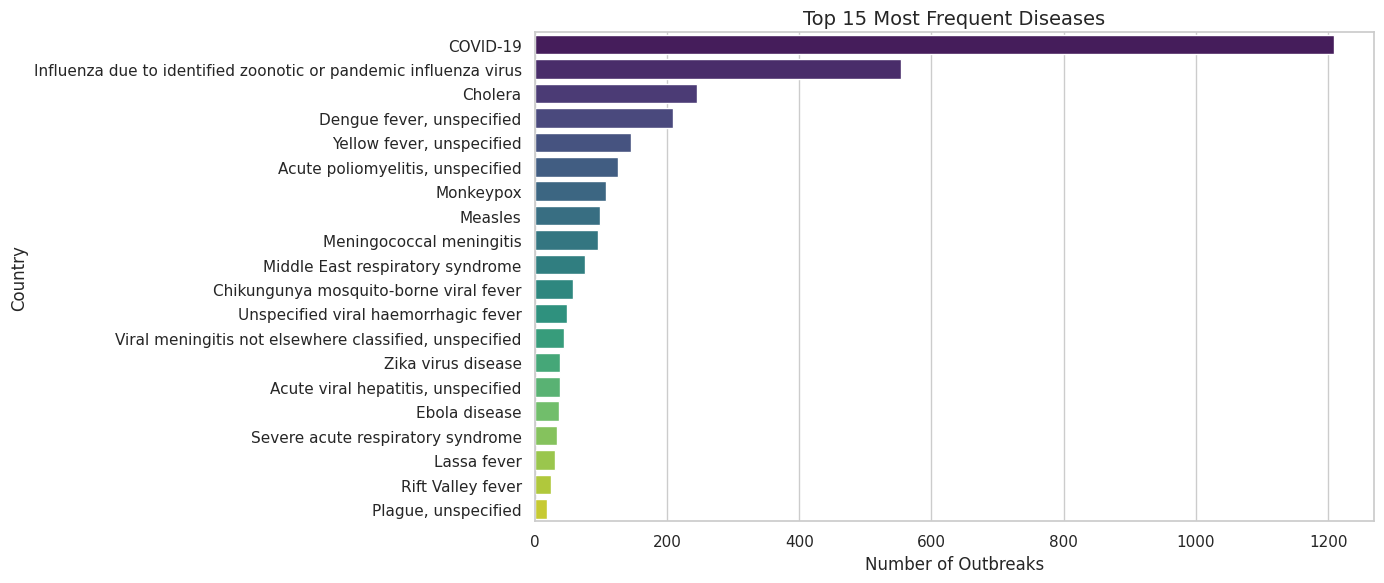

In [ ]:
top_diseases = df_clean['Disease'].value_counts().head(20)

plt.figure(figsize=(14, 6))

sns.barplot(
    x=top_diseases.values,
    y=top_diseases.index,
    hue=top_diseases.index,
    palette='viridis',
    legend=False
)

plt.title('Top 15 Most Frequent Diseases', fontsize=14)
plt.xlabel('Number of Outbreaks')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Observation:** COVID-19 and pandemic influenza dominate the outbreak counts due to their global spread. Cholera, polio, and yellow fever are also consistently high. This imbalance in disease frequency informs our encoding strategy.We will use label encoding rather than one-hot encoding for disease to avoid extremely high-dimensional sparse vectors.

### 3.4 Disease Category Distribution (ICD-10)

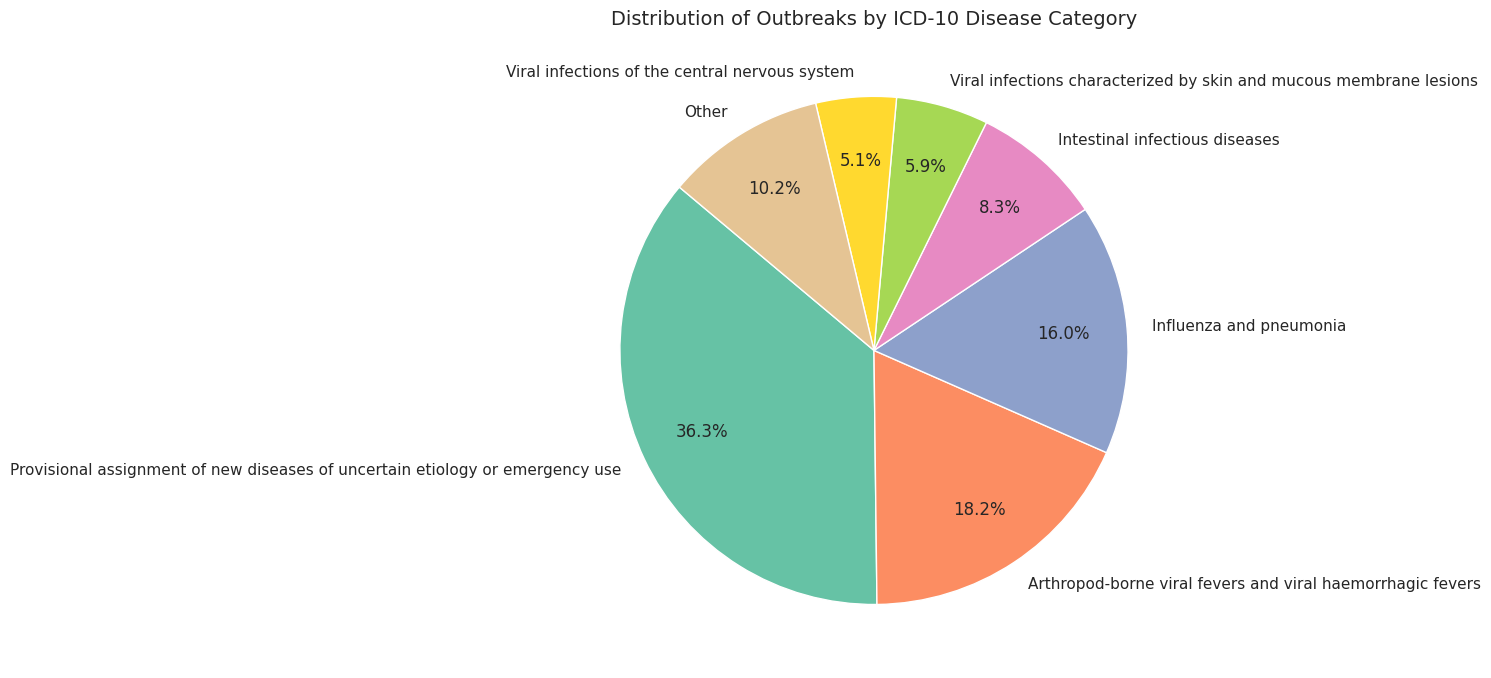

In [ ]:
category_counts = df_clean['icd10n'].value_counts()
top_n = 6# We used the top 6 and labelled the rest as others due to the fact of overlapping labels on the pie chart showing the category
top_cats = category_counts.head(top_n)
other_count = category_counts.iloc[top_n:].sum()
plot_data = pd.concat([top_cats, pd.Series({'Other': other_count})])

plt.figure(figsize=(12, 8))
plt.pie(plot_data.values, labels=plot_data.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('Set2', len(plot_data)),
        pctdistance=0.75, labeldistance=1.1)
plt.title('Distribution of Outbreaks by ICD-10 Disease Category', fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** The majority of outbreaks fall under a few broad ICD-10 disease categories. This high-level categorisation, icd10n, will serve as a useful feature for clustering since it groups diseases by biological similarity, reducing noise compared to using individual disease names.

### 3.5 Outbreaks per Continent (derived from iso3 region)

This count outbreaks per country and plot a heatmap-style count

In [ ]:
country_outbreak_counts = df_clean.groupby('Country').size().reset_index(name='outbreak_count')
print(f'Total unique countries: {country_outbreak_counts.shape[0]}')
print()
print('Top 10 countries:')
print(country_outbreak_counts.sort_values('outbreak_count', ascending=False).head(10))

Total unique countries: 236

Top 10 countries:
                                               Country  outbreak_count
45                    Congo Democratic Republic of the              79
154                                            Nigeria              60
224                           United States of America              51
41                                               China              49
28                                              Brazil              46
70                                              France              44
223  United Kingdom of Great Britain and Northern I...              43
39                                                Chad              40
153                                              Niger              40
220                                             Uganda              40


### 3.6 Outbreaks Over Time by Disease Category

This shows the top 5 disease categories over time.

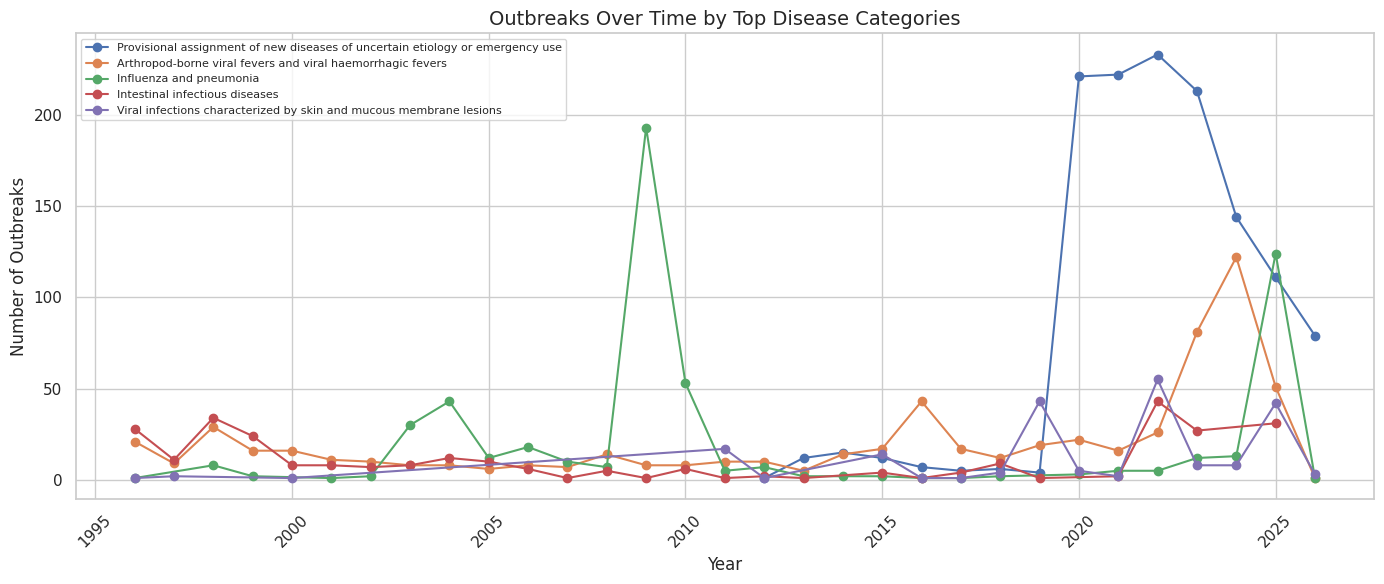

In [ ]:
top_cats = df_clean['icd10n'].value_counts().head(5).index
df_top = df_clean[df_clean['icd10n'].isin(top_cats)]

trend = df_top.groupby(['Year', 'icd10n']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))
for cat in top_cats:
    subset = trend[trend['icd10n'] == cat]
    plt.plot(subset['Year'], subset['count'], marker='o', label=cat)

plt.title('Outbreaks Over Time by Top Disease Categories', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Outbreaks')
plt.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Different disease categories show distinct temporal patterns. The sharp spike in one category around 2020 clearly corresponds to COVID-19. This temporal pattern confirms that Year is an informative feature that will contribute meaningfully to how clusters form.

## 4. Data Preprocessing

Machine learning models require numerical input. Our dataset is largely categorical, so we need to encode the relevant columns. We also need to engineer features that give the clustering algorithm meaningful numeric signals.

### 4.1 Feature Engineering

Rather than clustering individual outbreak records, which would give trivial results since each row is already unique, we aggregate the data at the country level to create a feature vector per country. This is the more meaningful clustering unit ,thus, grouping countries by their outbreak profiles.

Features we will create per country:
- `total_outbreaks` — total number of unique outbreaks recorded
- `unique_diseases` — number of distinct diseases reported
- `year_span` — range of years in which outbreaks were recorded
- `most_common_category_encoded` — encoded label of the most frequently occurring disease category
- `avg_year` — average year of outbreaks.

In [ ]:
#Feature engineering — aggregate by country
# Assisted by Claude AI, adapted for this dataset

country_features = df_clean.groupby('Country').agg(
    total_outbreaks=('Disease', 'count'),
    unique_diseases=('Disease', 'nunique'),
    year_span=('Year', lambda x: x.max() - x.min()),
    avg_year=('Year', 'mean'),
    most_common_category=('icd10n', lambda x: x.mode()[0])
).reset_index()

print(f'Country-level feature matrix shape: {country_features.shape}')
country_features.head(10)

Country-level feature matrix shape: (236, 6)


,Country,total_outbreaks,unique_diseases,year_span,avg_year,most_common_category
0,Afghanistan,27,13,27,2010.629630,Intestinal infectious diseases
1,Albania,10,4,29,2017.600000,Provisional assignment of new diseases of unce...
2,Algeria,16,8,30,2017.312500,Provisional assignment of new diseases of unce...
3,American Samoa,5,3,14,2018.800000,Provisional assignment of new diseases of unce...
4,Andorra,5,2,14,2019.000000,Provisional assignment of new diseases of unce...
5,Angola,23,10,29,2011.652174,Viral infections of the central nervous system
6,Anguilla,4,2,3,2021.500000,Provisional assignment of new diseases of unce...
7,Antigua and Barbuda,7,4,16,2020.571429,Arthropod-borne viral fevers and viral haemorr...
8,Argentina,21,11,30,2020.000000,Provisional assignment of new diseases of unce...
9,Armenia,10,3,28,2019.300000,Provisional assignment of new diseases of unce...


### 4.2 Encoding Categorical Variables

The `most_common_category` column is categorical text. We use **Label Encoding** here rather than one-hot encoding because:
- The number of unique ICD-10 categories is manageable but would still create many binary columns with one-hot encoding
- K-Means uses Euclidean distance and label encoding preserves ordinality more compactly
- For DBSCAN we will test sensitivity to this choice

In [ ]:
#Label encode the most_common_category column
le = LabelEncoder()
country_features['category_encoded'] = le.fit_transform(country_features['most_common_category'])

print('Category encoding mapping:')
for i, label in enumerate(le.classes_):
    print(f'  {i} → {label}')

Category encoding mapping:
  0 → Arthropod-borne viral fevers and viral haemorrhagic fevers
  1 → Certain zoonotic bacterial diseases
  2 → Influenza and pneumonia
  3 → Intestinal infectious diseases
  4 → Other bacterial diseases
  5 → Other viral diseases
  6 → Provisional assignment of new diseases of uncertain etiology or emergency use
  7 → Viral infections characterized by skin and mucous membrane lesions
  8 → Viral infections of the central nervous system


### 4.3 Selecting Features and Scaling

We select the numeric features for clustering and apply **StandardScaler** to normalise them. This is essential because:
- `total_outbreaks` can range from 1 to 50+, while `category_encoded` ranges from 0 to ~10
- K-Means and DBSCAN are both distance-based algorithms — without scaling, features with larger numeric ranges will dominate the distance calculation unfairly
- StandardScaler transforms each feature to have mean=0 and std=1

In [ ]:
# Select features for clustering
features = ['total_outbreaks', 'unique_diseases', 'year_span', 'avg_year', 'category_encoded']
X = country_features[features]

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Mean after scaling (should be ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'Std after scaling (should be ~1): {X_scaled.std(axis=0).round(4)}')

Feature matrix shape: (236, 5)
Mean after scaling (should be ~0): [ 0. -0. -0. -0.  0.]
Std after scaling (should be ~1): [1. 1. 1. 1. 1.]


## 5. Modelling

We will train two clustering models and compare their performance:
1. **K-Means** — centroid-based clustering; well-suited for compact, spherical clusters
2. **DBSCAN** — density-based clustering; can find arbitrarily shaped clusters and identify outliers

### 5.1 Model 1: K-Means Clustering

**Why K-Means?**  
K-Means is a natural first choice for this type of tabular clustering task. It is computationally efficient, interpretable, and well-supported by evaluation metrics like inertia and silhouette score. It works by assigning each data point to the nearest cluster centroid and iteratively updating centroids until convergence.

**Choosing K — The Elbow Method:**  
We first need to determine the optimal number of clusters. We use the elbow method, which plots inertia, within-cluster sum of squares, against K and identifies the point where additional clusters yield diminishing returns.

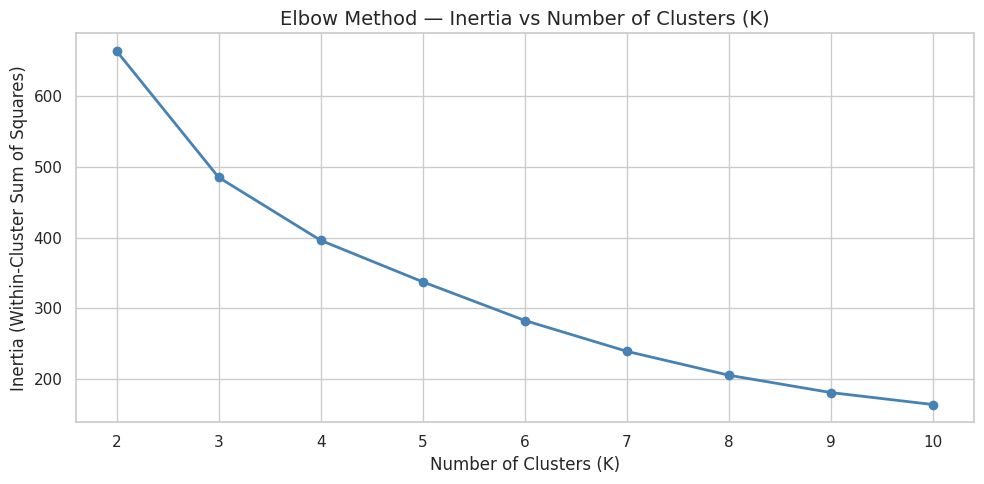

In [ ]:
# Elbow method to find optimal K
# Assisted by Claude AI, adapted for this dataset
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia_values, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Inertia vs Number of Clusters (K)', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

**Observation:** Identify the 'elbow' point in the plot above, the K value where inertia begins to decrease more slowly. This is our optimal K.

In [ ]:
# Train K-Means with optimal K
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_model = kmeans.fit_predict(X_scaled)
# Cluster labels to the country features dataframe
country_features['kmeans_cluster'] = kmeans_model

print(f'K-Means trained with K={OPTIMAL_K}')
print()
print('Cluster sizes:')
print(country_features['kmeans_cluster'].value_counts().sort_index())

K-Means trained with K=3

Cluster sizes:
kmeans_cluster
0    101
1     90
2     45
Name: count, dtype: int64


### 5.2 Model 2: DBSCAN Clustering

**Why DBSCAN?**  
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) does not require us to specify the number of clusters upfront. It groups points that are densely packed together and marks isolated points as outliers (noise). This is useful for our dataset because some countries may have unusual outbreak profiles that don't fit neatly into any cluster.DBSCAN will label those as noise rather than forcing them into a cluster.

**Key hyperparameters:**
- `eps` — the maximum distance between two points to be considered neighbours
- `min_samples` — minimum number of points required to form a dense region.

In [ ]:
# Train DBSCAN
# eps and min_samples are tuned by trial — update if results are poor
# Assisted by Claude AI, adapted for this dataset
dbscan = DBSCAN(eps=1.2, min_samples=3)
dbscan_model = dbscan.fit_predict(X_scaled)

country_features['dbscan_cluster'] = dbscan_model

n_clusters_db = len(set(dbscan_model)) - (1 if -1 in dbscan_model else 0)
n_noise = list(dbscan_model).count(-1)

print(f'DBSCAN results:')
print(f'  Number of clusters found: {n_clusters_db}')
print(f'  Number of noise points (outliers): {n_noise}')
print()
print('Cluster distribution (−1 = noise/outlier):')
print(country_features['dbscan_cluster'].value_counts().sort_index())

DBSCAN results:
  Number of clusters found: 3
  Number of noise points (outliers): 12

Cluster distribution (−1 = noise/outlier):
dbscan_cluster
-1     12
 0     41
 1    173
 2     10
Name: count, dtype: int64


---
## 6. Evaluation

We evaluate both models using the metrics required for clustering projects:
- **Inertia** (K-Means only) — measures how tight the clusters are internally
- **Silhouette Score** — measures how well-separated clusters are (range: −1 to 1; higher is better)
- **Cluster visualisation** — using PCA to reduce dimensions to 2D for plotting

### 6.1 Inertia (K-Means)

In [ ]:
print(f'K-Means Inertia (Within-Cluster Sum of Squares): {kmeans.inertia_:.4f}')
print()

K-Means Inertia (Within-Cluster Sum of Squares): 485.3669



Interpretation:


* Inertia Value: The K-Means model achieved an inertia (Within-Cluster Sum of Squares) of 485.3669.
* Meaning: Lower inertia indicates tighter, more compact clusters where data points are closer to their respective centroids.
* Context: Based on our earlier elbow plot, this value represents the point (K=3) where we successfully captured the sharpest drop in inertia before hitting diminishing returns.




### 6.2 Silhouette Scores

In [ ]:
# Silhouette score for K-Means
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
print(f'K-Means Silhouette Score: {sil_kmeans:.4f}')

# Silhouette score for DBSCAN (only if more than 1 cluster and not all noise)
if n_clusters_db > 1:
    # Exclude noise points for silhouette calculation
    mask = dbscan_labels != -1
    if mask.sum() > 1:
        sil_dbscan = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        print(f'DBSCAN Silhouette Score,that is, excluding noise: {sil_dbscan:.4f}')
    else:
        print('DBSCAN: Not enough non-noise points to compute silhouette score.')
else:
    print('DBSCAN: Only one cluster found — silhouette score not applicable.')
    print('Consider tuning eps and min_samples parameters.')

print()
print('Silhouette Score interpretation:')
print('  Close to +1: clusters are well-separated and compact')
print('  Close to 0: clusters are overlapping')
print('  Negative: points may be in the wrong cluster')

K-Means Silhouette Score: 0.3685
DBSCAN Silhouette Score,that is, excluding noise: 0.3435

Silhouette Score interpretation:
  Close to +1: clusters are well-separated and compact
  Close to 0: clusters are overlapping
  Negative: points may be in the wrong cluster


### 6.3 Cluster Visualisation — K-Means (PCA 2D)

PCA explained variance: PC1=64.45%, PC2=14.69%, Total=79.14%


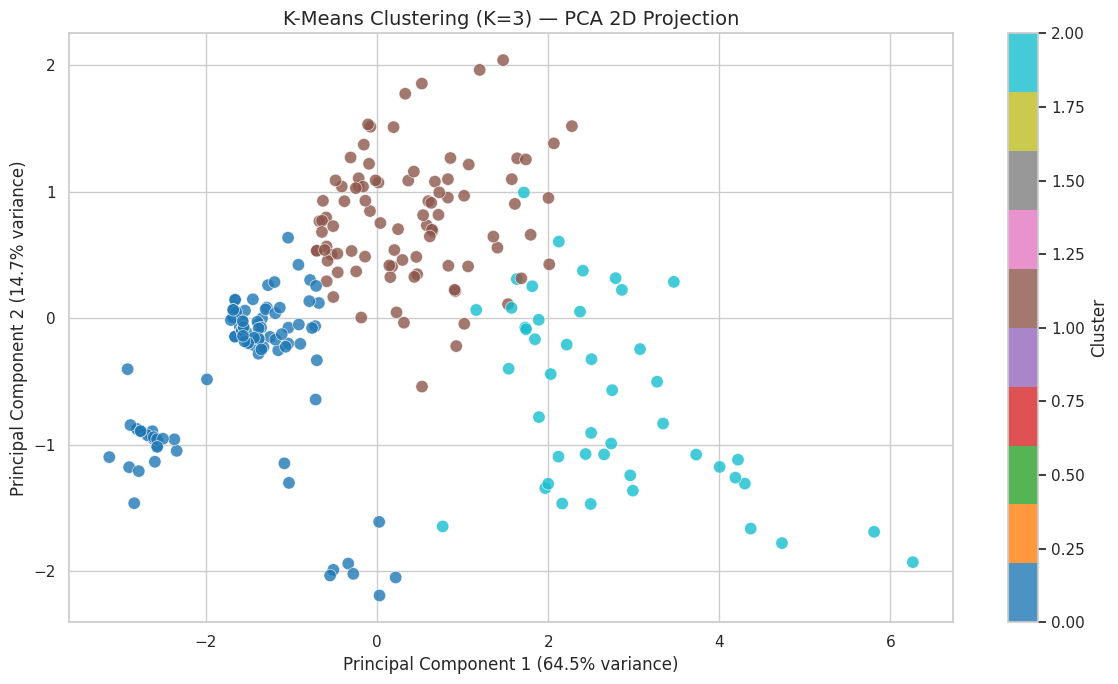

In [ ]:
# Reduce to 2D using PCA for visualisation
# PCA is used here only for plotting — not for clustering
# Assisted by Claude AI, adapted for this dataset
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PCA explained variance: PC1={explained[0]:.2%}, PC2={explained[1]:.2%}, Total={sum(explained):.2%}')

plt.figure(figsize=(12, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=kmeans_labels, cmap='tab10', s=80, alpha=0.8, edgecolors='white', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clustering (K={OPTIMAL_K}) — PCA 2D Projection', fontsize=14)
plt.xlabel(f'Principal Component 1 ({explained[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({explained[1]:.1%} variance)')
plt.tight_layout()
plt.show()

### 6.4 Cluster Visualisation — DBSCAN (PCA 2D)

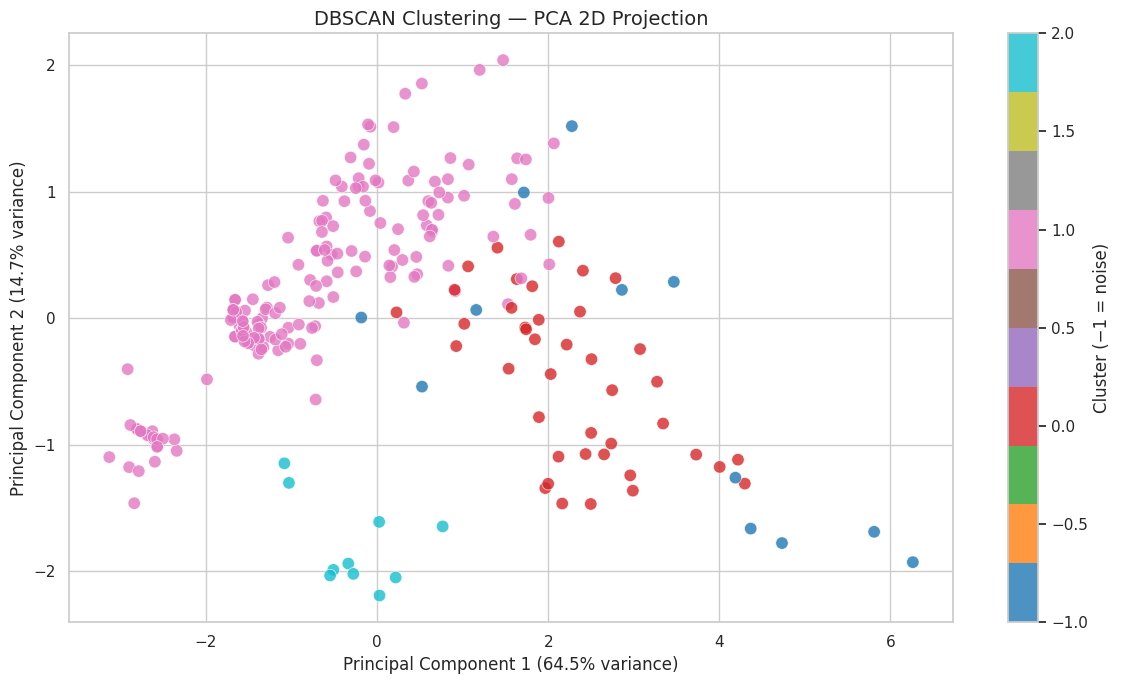

In [ ]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=dbscan_labels, cmap='tab10', s=80, alpha=0.8, edgecolors='white', linewidth=0.5)
plt.colorbar(scatter, label='Cluster (−1 = noise)')
plt.title('DBSCAN Clustering — PCA 2D Projection', fontsize=14)
plt.xlabel(f'Principal Component 1 ({explained[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({explained[1]:.1%} variance)')
plt.tight_layout()
plt.show()

### 6.5 Cluster Profile Analysis — What Does Each Cluster Represent?

In [ ]:
# Analyse the characteristics of each K-Means cluster
cluster_profiles = country_features.groupby('kmeans_cluster')[features].mean().round(2)
print('Average feature values per K-Means cluster:')
print(cluster_profiles)
print()

# Sample countries per cluster
print('Sample countries per cluster:')
for cluster_id in sorted(country_features['kmeans_cluster'].unique()):
    countries = country_features[country_features['kmeans_cluster'] == cluster_id]['Country'].head(5).tolist()
    print(f'  Cluster {cluster_id}: {countries}')

Average feature values per K-Means cluster:
                total_outbreaks  unique_diseases  year_span  avg_year  \
kmeans_cluster                                                          
0                          7.98             3.23      13.12   2020.43   
1                         15.48             6.66      26.40   2016.39   
2                         29.80            11.87      27.98   2013.90   

                category_encoded  
kmeans_cluster                    
0                           5.50  
1                           5.72  
2                           1.09  

Sample countries per cluster:
  Cluster 0: ['American Samoa', 'Andorra', 'Anguilla', 'Antigua and Barbuda', 'Aruba']
  Cluster 1: ['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia']
  Cluster 2: ['Afghanistan', 'Bolivia (Plurinational State of)', 'Brazil', 'Burkina Faso', 'Burundi']


### 6.6 Confusion Matrix Equivalent — Cluster Size Comparison

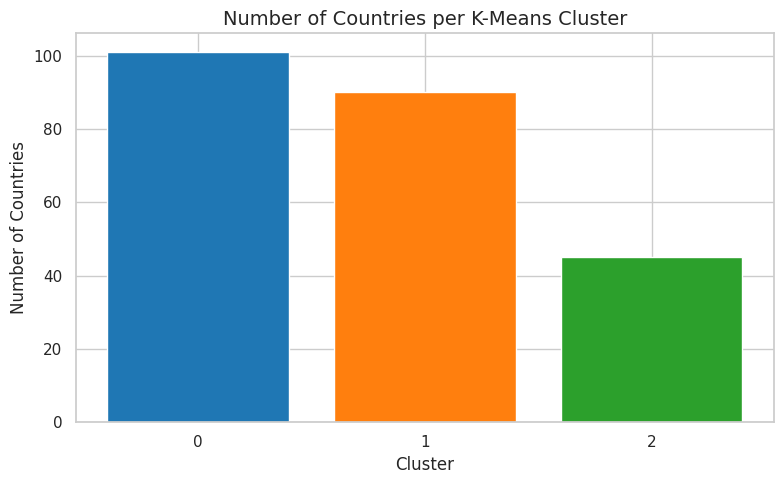

Cluster sizes:
kmeans_cluster
0    101
1     90
2     45
Name: count, dtype: int64


In [ ]:
# Compare K-Means cluster sizes visually
cluster_counts = country_features['kmeans_cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index, cluster_counts.values, color=sns.color_palette('tab10', len(cluster_counts)))
plt.title('Number of Countries per K-Means Cluster', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Number of Countries')
plt.xticks(cluster_counts.index)
plt.tight_layout()
plt.show()

print('Cluster sizes:')
print(cluster_counts)

### 6.7 Model Comparison Summary

In [ ]:
print('=' * 55)
print('         MODEL COMPARISON SUMMARY')
print('=' * 55)
print(f'  K-Means (K={OPTIMAL_K})')
print(f'    Inertia:          {kmeans.inertia_:.4f}')
print(f'    Silhouette Score: {sil_kmeans:.4f}')
print(f'    Clusters found:   {OPTIMAL_K}')
print(f'    Noise points:     0 (K-Means assigns all points)')
print()
print(f'  DBSCAN (eps=1.2, min_samples=3)')
print(f'    Clusters found:   {n_clusters_db}')
print(f'    Noise points:     {n_noise}')
if n_clusters_db > 1 and mask.sum() > 1:
    print(f'    Silhouette Score: {sil_dbscan:.4f}')
print('=' * 55)
print()

         MODEL COMPARISON SUMMARY
  K-Means (K=3)
    Inertia:          485.3669
    Silhouette Score: 0.3685
    Clusters found:   3
    Noise points:     0 (K-Means assigns all points)

  DBSCAN (eps=1.2, min_samples=3)
    Clusters found:   3
    Noise points:     12
    Silhouette Score: 0.3435



**Model Comparison Interpretation:**
1. Silhouette Score Comparison

  K-Means (K=3): Achieved a silhouette score of 0.3685.

   DBSCAN (eps=1.2,min_samples=3): Achieved a silhouette score of 0.3435 (excluding noise).

  Takeaway: K-Means produced marginally better-separated and more cohesive clusters globally compared to DBSCAN, even when giving DBSCAN the advantage of ignoring its noise points.

2. Meaningfulness of Groupings

 K-Means successfully isolated distinct disease profiles:

   * Cluster 0 (Low Outbreaks/Low Diversity): Represents baseline or isolated locations (e.g., American Samoa, Andorra) with low total outbreaks (avg. 7.98) and very few unique diseases (avg. 3.23).

   * Cluster 1 (Moderate Outbreaks/Moderate Diversity): Countries with intermediate activity spanning longer observation timelines.

   * Cluster 2 (High Outbreaks/High Diversity): Represents high-burden regions (e.g., Afghanistan, Burkina Faso, Burundi) suffering from chronic outbreaks (avg. 29.80) across a massive variety of unique diseases (avg. 11.87).

  DBSCAN Weaknesses: DBSCAN struggled with the varying density of the dataset. It dumped the vast majority of data points into a single giant cluster (seen in the pink group on the PCA plot) while identifying 12 countries as outright noise (-1) and creating tiny, fractional clusters elsewhere.

3. Algorithmic Strengths and Weaknesses

   K-Means:
   * Strength: Created clean, well-apportioned groupings that capture a clear gradient of low, medium, and high disease burdens.

    * Weakness: It forces every single country into a cluster, meaning genuine anomalies are dragged into standard groups, potentially inflating cluster sizes (e.g., Cluster 0 has 101 countries).

   DBSCAN:

    * Strength: Successfully filtered out 12 extreme outlier countries as noise, keeping them from distorting cluster definitions.

    * Weakness: Extremely sensitive to density parameters. It suffers from the "one big cluster" phenomenon here, failing to partition the core bulk of global outbreak profiles effectively.

4. Final Recommendation

We recommend the K-Means (K=3) model for this dataset. It provides a far more actionable and interpretable stratification of countries based on public health risk and historical outbreak density, backed by a superior silhouette score and clean separation on the PCA 2D projection.


**Limitations:**
- The dataset only records whether an outbreak occurred in a country in a given year — it does not include the number of cases or deaths, which limits the severity dimension of our analysis.
- Data is reported at the national level only — sub-national patterns cannot be captured.
- Label encoding for disease category introduces an implicit ordinal relationship that may not reflect true disease similarity.

## 7. Conclusion

This project applied K-Means and DBSCAN clustering to a globally comprehensive WHO disease outbreak dataset spanning 1996–2026. By aggregating outbreak data at the country level and engineering meaningful features, we were able to identify natural groupings of countries based on their disease outbreak profiles.

**Key Findings & Representations**

Our analysis successfully mapped countries into low, medium, and high-burden categories. The high-burden cluster (Cluster 2) uniquely captures territories dealing with complex, multi-disease environments, mirroring known systemic challenges highlighted in epidemiological literature.

**Model Performance & Rationale**

The K-Means model outperformed DBSCAN. It achieved a higher silhouette score (0.3685 vs 0.3435) and avoided DBSCAN's flaw of over-condensing the dataset into a single massive cluster. K-Means effectively balanced the cluster distribution across 101, 90, and 45 countries respectively.

In [ ]:
import joblib

joblib.dump(kmeans_model, 'disease_clustering_model.pkl')

['disease_clustering_model.pkl']